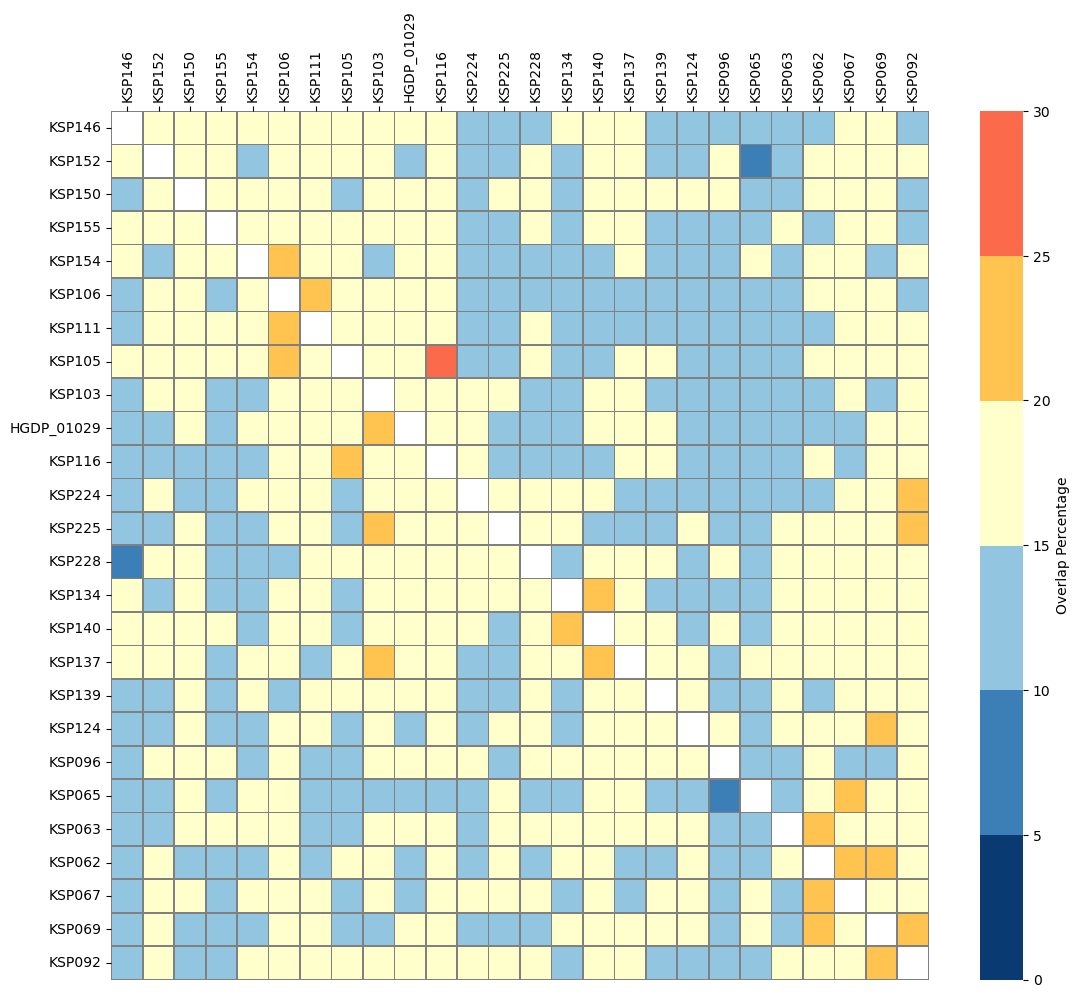

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import os

# Load the list of individuals
with open('all.San.ind', 'r') as file:
    individuals = [line.strip() for line in file]

# Initialize an empty dictionary to store regions
regions_dict = {ind: [] for ind in individuals}

# Read regions from BED files
for ind in individuals:
    bed_file = f'{ind}_overlap.bed'
    if os.path.exists(bed_file):
        regions = pd.read_csv(bed_file, sep='\t', header=None, names=['chrom', 'start', 'end'])
        regions_dict[ind] = regions

# Create a DataFrame to store the overlap percentages
overlap_matrix = pd.DataFrame(0.0, index=individuals, columns=individuals, dtype=float)

# Calculate overlaps more efficiently
for ind1 in individuals:
    regions1 = regions_dict[ind1]
    len_regions1 = len(regions1)
    for ind2 in individuals:
        regions2 = regions_dict[ind2]
        overlap_count = 0
        for _, row1 in regions1.iterrows():
            overlap_count += ((regions2['chrom'] == row1['chrom']) & 
                              (regions2['start'] <= row1['end']) & 
                              (regions2['end'] >= row1['start'])).sum()
        overlap_percentage = (overlap_count / len_regions1) * 100 if len_regions1 > 0 else 0
        overlap_matrix.loc[ind1, ind2] = overlap_percentage

# Specify the custom order of the rows and columns
custom_order = ["KSP146", "KSP152", "KSP150","KSP155", "KSP154",  "KSP106", "KSP111", "KSP105","KSP103",  "KSP116","KSP224", "KSP225", "KSP228", "KSP134", "KSP140","KSP137", "KSP139", "KSP124", "KSP096", "KSP065","KSP063",  "KSP062", "KSP067", "KSP069", "KSP092"]

# Reorder the overlap matrix
ordered_overlap_matrix = overlap_matrix.loc[custom_order, custom_order]
ordered_overlap_matrix.index = custom_order
ordered_overlap_matrix.columns = custom_order

# Mask for the diagonal
mask = np.zeros_like(ordered_overlap_matrix, dtype=bool)
np.fill_diagonal(mask, True)

# Define custom color palette and boundaries
colors = ["#0a3a72", "#3c7fb7", "#92c5e0", "#ffffcc", "#fec44f", "#fb6a4a"]
cmap = ListedColormap(colors)
bounds = [0, 5, 10, 15, 20, 25, 30]
norm = BoundaryNorm(bounds, cmap.N)

# Plot the heatmap without dendrogram and without annotations
plt.figure(figsize=(12, 10))
ax = sns.heatmap(ordered_overlap_matrix, cmap=cmap, norm=norm, annot=False, mask=mask, cbar_kws={'label': 'Overlap Percentage'}, linewidths=.5, linecolor='grey', xticklabels=False)

# Add column labels to the top
ax.set_xticks(np.arange(len(custom_order)) + 0.5)
ax.set_xticklabels(custom_order, rotation=90, ha='center')

# Move x-axis labels to the top
ax.xaxis.tick_top()

# Add extra space at the top
plt.subplots_adjust(top=20)  # Adjust the top margin as needed
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


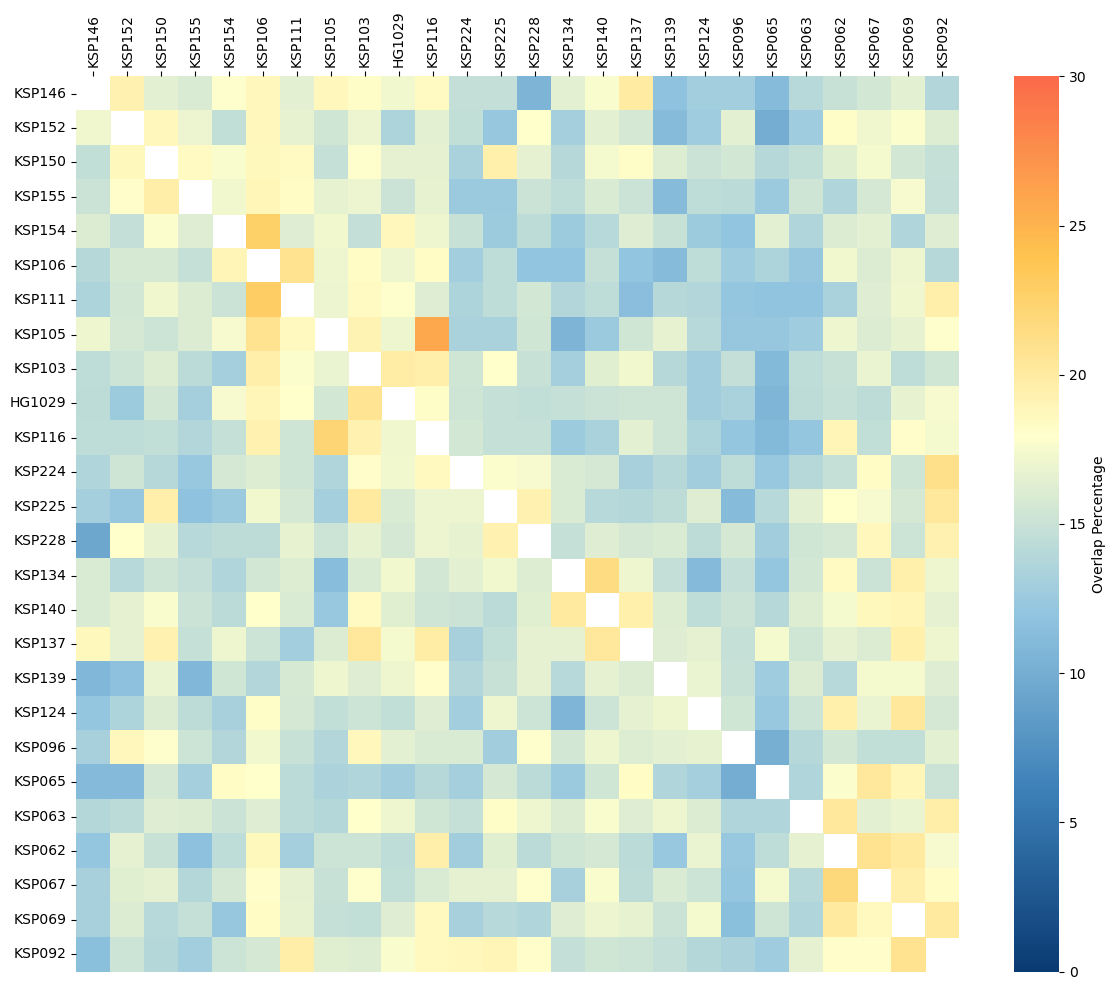

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os

# Load the list of individuals
with open('all.San.ind', 'r') as file:
    individuals = [line.strip() for line in file]

# Initialize an empty dictionary to store regions
regions_dict = {ind: [] for ind in individuals}

# Read regions from BED files
for ind in individuals:
    bed_file = f'{ind}_overlap.bed'
    if os.path.exists(bed_file):
        regions = pd.read_csv(bed_file, sep='\t', header=None, names=['chrom', 'start', 'end'])
        regions_dict[ind] = regions

# Create a DataFrame to store the overlap percentages
overlap_matrix = pd.DataFrame(0.0, index=individuals, columns=individuals, dtype=float)

# Calculate overlaps more efficiently
for ind1 in individuals:
    regions1 = regions_dict[ind1]
    len_regions1 = len(regions1)
    for ind2 in individuals:
        regions2 = regions_dict[ind2]
        overlap_count = 0
        for _, row1 in regions1.iterrows():
            overlap_count += ((regions2['chrom'] == row1['chrom']) & 
                              (regions2['start'] <= row1['end']) & 
                              (regions2['end'] >= row1['start'])).sum()
        overlap_percentage = (overlap_count / len_regions1) * 100 if len_regions1 > 0 else 0
        overlap_matrix.loc[ind1, ind2] = overlap_percentage

# Specify the custom order of the rows and columns
custom_order = ["KSP146", "KSP152", "KSP150","KSP155", "KSP154",  "KSP106", "KSP111", "KSP105","KSP103", "HGDP_HGDP01029",   "KSP116","KSP224", "KSP225", "KSP228", "KSP134", "KSP140","KSP137", "KSP139", "KSP124", "KSP096", "KSP065","KSP063",  "KSP062", "KSP067", "KSP069", "KSP092"]

# Shorten specific sample names
name_mapping = {
    "HGDP_HGDP01029": "HG1029"
}
short_custom_order = [name_mapping.get(name, name) for name in custom_order]

# Reorder the overlap matrix
ordered_overlap_matrix = overlap_matrix.loc[custom_order, custom_order]
ordered_overlap_matrix.index = short_custom_order
ordered_overlap_matrix.columns = short_custom_order

# Mask for the diagonal
mask = np.zeros_like(ordered_overlap_matrix, dtype=bool)
np.fill_diagonal(mask, True)

# Define custom color palette and boundaries
colors = ["#0a3a72", "#3c7fb7", "#92c5e0", "#ffffcc", "#fec44f", "#fb6a4a"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

# Plot the heatmap without dendrogram and without annotations
plt.figure(figsize=(12, 10))
ax = sns.heatmap(ordered_overlap_matrix, cmap=cmap, annot=False, mask=mask, cbar_kws={'label': 'Overlap Percentage'}, vmin=0, vmax=30, linewidths=0)

# Add column labels to the top
ax.set_xticks(np.arange(len(short_custom_order)) + 0.5)
ax.set_xticklabels(short_custom_order, rotation=90, ha='center')

# Move x-axis labels to the top
ax.xaxis.tick_top()

# Add extra space at the top
plt.subplots_adjust(top=0.8)  # Adjust the top margin as needed
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()
